To generate and export PSS_Seq [0,1,2]

In [18]:
## import requirement
import numpy as np
import scipy
import csv
import matplotlib.pyplot as plt
!python3 -m pip install py3gpp
from py3gpp import *

In [19]:
## initial parameter
sampleRate = 15.36e6
nrbSSB = 20
mu = 1
scs = 15 * 2**mu
carrier = nrCarrierConfig(NSizeGrid = nrbSSB, SubcarrierSpacing = scs)
rxOfdmInfo = nrOFDMInfo(carrier)
Nfft = rxOfdmInfo['Nfft']  

# find CFO (coarseFrequencyOffset)
kPSS = np.arange((119-63), (119+64))    # np.arange(56, 183) # check on 3GPP standard 

# With downsampling
syncNfft = 256                  # minimum FFT Size to cover SS burst
syncSR = syncNfft * scs * 1e3

/home/chatchamon/workarea/npn_5g/bladeRF_txrx/based_IQ_find_NID2/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chatchamon/workarea/npn_5g/bladeRF_txrx/based_IQ_find_NID2/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


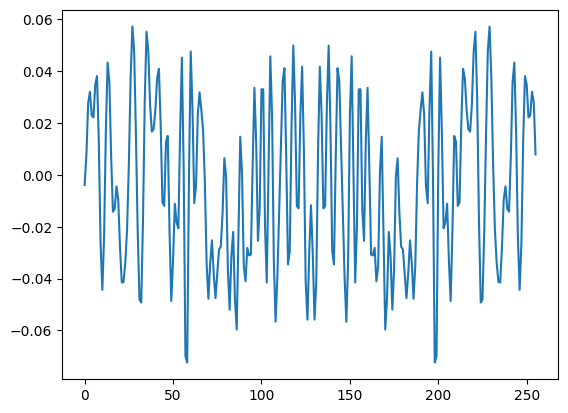

In [20]:
# refWaveform from PSS seq
nSlot = 0

# input NID
NID2 = 0

slotGrid = nrResourceGrid(carrier)
slotGrid  = slotGrid[:,0] 
slotGrid[kPSS] = nrPSS(NID2)

[refWaveform, info] = nrOFDMModulate(carrier=carrier, grid=slotGrid, scs=scs, initialNSlot=nSlot, SampleRate=syncSR, Nfft=syncNfft)     # mod w/ downsample sample rate
refWaveform = refWaveform[info['CyclicPrefixLengths'][0]:]; # remove CP

plt.plot(refWaveform)
plt.show()